# TFM_Customer_Reviews_Sentiment_Analysis


##  Loading python libraries and files


In [35]:
import pandas as pd
import numpy as np
import re
import os
from collections import Counter

import spacy
from spacy.language import Language

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import scipy.sparse as sp

from xgboost import XGBClassifier

In [3]:
from google.colab import userdata
token = userdata.get('GITHUB_TOKEN')

In [23]:
# Use it with !wget to load the dataset from GitHub
!wget --header="Authorization: token {token}" https://raw.githubusercontent.com/lucaiaco21/Cafe-Madrid---TFM-Project/refs/heads/main/5.Modelo_text_mining/cleaned_reviews_df_v20260114_2016PM.tsv

--2026-01-14 21:21:09--  https://raw.githubusercontent.com/lucaiaco21/Cafe-Madrid---TFM-Project/refs/heads/main/5.Modelo_text_mining/cleaned_reviews_df_v20260114_2016PM.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 537329 (525K) [text/plain]
Saving to: ‘cleaned_reviews_df_v20260114_2016PM.tsv.1’

cleaned_reviews_df_ 100%[===================>] 524.74K  --.-KB/s    in 0.02s   

2026-01-14 21:21:09 (24.4 MB/s) - ‘cleaned_reviews_df_v20260114_2016PM.tsv.1’ saved [537329/537329]



## Considering EMOJIS in Tokenization and Lemmatization processes

### Strategy
Tokenization Fix: We will use a regex-based replacement to turn multi-word emoji descriptions into single tokens (e.g., red_heart).

Lemmatization Fix: We will implement a custom spaCy Attribute Ruler or a custom component to ensure that any token containing an underscore (our emoji tokens) is excluded from the standard lemmatization process.

### The Implementation Code

In [8]:
# Load spaCy
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

# --- Automated Phrase Detection ---
def get_dynamic_emoji_phrases(df, top_n=20):
    # This regex finds text between colons or common emoji-word patterns
    # but based on your TSV, it's plain text. We look for multi-word emoji names.
    all_text = " ".join(df['text_en_with_emoji'].fillna('').astype(str))
    words = all_text.split()
    bigrams = zip(words, words[1:])
    counts = Counter(bigrams)

    # Define keywords that signal an emoji description
    emoji_keywords = {
    'heart', 'face', 'star', 'hands', 'smiling', 'eyes', 'thumb',
    'skull', 'rolling', 'angry', 'sad', 'cry', 'pouting', 'weary',
    'broken', 'expressionless', 'thinking', 'middle'
    }

    detected = []
    for (w1, w2), count in counts.most_common(100):
        if w1 in emoji_keywords or w2 in emoji_keywords:
            detected.append(f"{w1} {w2}")
    return list(set(detected + ["red heart", "smiling face", "heart eyes"]))

# Load your data first to feed the detector
df = pd.read_csv('cleaned_reviews_df_v20260114_2016PM.tsv', sep='\t')
EMOJI_PHRASES = get_dynamic_emoji_phrases(df)

def join_emoji_phrases_final(text):
    if not isinstance(text, str): return ""

    # Sort by length descending to catch longest phrases first
    sorted_phrases = sorted(EMOJI_PHRASES, key=len, reverse=True)

    for phrase in sorted_phrases:
        # \b ensures we match the whole phrase, and we check it's not preceded by 'emoji_'
        pattern = r'\b' + re.escape(phrase) + r'\b'

        # We only replace if the phrase isn't already prefixed
        # This prevents "smiling face" becoming "emoji_smiling_face"
        # and then later "face" turning it into "emoji_smiling_emoji_face"
        text = re.sub(pattern, "emoji_" + phrase.replace(" ", "_"), text)

    # Clean up any accidental double prefixes like emoji_emoji_
    text = text.replace("emoji_emoji_", "emoji_")
    return text

# --- Custom Shield: keep emoji tokens intact through lemmatization ---
@Language.component("emoji_preserver")
def emoji_preserver(doc):
    for token in doc:
        if "emoji_" in token.text:
            # Shield Lemma
            token.lemma_ = token.text

            # Shield Stopword Status (must modify the vocabulary entry, not the token property)
            token.vocab[token.text].is_stop = False
    return doc

# Ensure the pipe is added
if "emoji_preserver" not in nlp.pipe_names:
    nlp.add_pipe("emoji_preserver", before="lemmatizer")

# --- Final Preprocessing ---
def preprocess_v2(text):
    text = join_emoji_phrases_final(text)
    doc = nlp(text)

    clean_tokens = []
    for token in doc:
        # Check if it's our emoji token
        if "emoji_" in token.text:
            clean_tokens.append(token.text)

        # For regular words, we check is_stop.
        # Because of the fix above, our emoji tokens will return False here.
        elif not token.is_stop and not token.is_punct and token.is_alpha:
            lemma = token.lemma_.lower()
            if len(lemma) > 1:
                clean_tokens.append(lemma)

    return " ".join(clean_tokens)

# Apply
df['text_final_v2'] = df['text_en_with_emoji'].apply(preprocess_v2)

### Verification checks

#### 1. The "Feature Survival" Verification

In [ ]:
# Combine all processed text
all_final_words = " ".join(df['text_final_v2'].fillna('')).split()

# Count occurrences of our custom emoji tokens
emoji_counts = Counter([word for word in all_final_words if word.startswith("emoji_")])

print("--- Emoji Token Survival Report ---")
if not emoji_counts:
    print("No emoji tokens found. Check if EMOJI_PHRASES matches your text.")
else:
    for emoji, count in emoji_counts.most_common(10):
        print(f"{emoji}: {count} occurrences")

--- Emoji Token Survival Report ---
emoji_smiling_face: 52 occurrences
emoji_red_heart: 20 occurrences
emoji_heart_eyes: 14 occurrences
emoji_face_with: 7 occurrences


#### 2. The "Sentiment Weight" Check (The TFM 'Golden' Insight)

INTERPRETATION ANALYSIS:
- We have discovered "Pure Predictors". This means that in your specific dataset (Cafe Madrid), when a user takes the time to include an emoji, it is currently a 100% guaranteed signal that the review is positive.
- The Insight: Emojis are not just "extra text"; they are "Sentiment Anchors."  
- The Impact: Your model can now classify these reviews with near-perfect confidence. Without the emoji_... tokens, the model would have to rely on generic words like "food" or "place," which appear in both positive and negative reviews.

In [10]:
# Create a cross-tabulation of Emojis vs Sentiment
# We extract the first emoji found in each review (if any)
def get_first_emoji(text):
    found = [word for word in text.split() if word.startswith("emoji_")]
    return found[0] if found else "no_emoji"

df['primary_emoji'] = df['text_final_v2'].apply(get_first_emoji)

# Filter for rows that actually have an emoji
emoji_df = df[df['primary_emoji'] != "no_emoji"]

# Look at the relationship
emoji_sentiment_dist = pd.crosstab(emoji_df['primary_emoji'], emoji_df['sentiment_3way'], normalize='index') * 100
print("\n--- Sentiment Concentration by Emoji (%) ---")
display(emoji_sentiment_dist.round(2))


--- Sentiment Concentration by Emoji (%) ---


sentiment_3way,pos
primary_emoji,
emoji_face_with,100.0
emoji_heart_eyes,100.0
emoji_red_heart,100.0
emoji_smiling_face,100.0


## Extracting Most Cited Names (NER)

In [12]:
# NER requires a spaCy pipeline with entity recognition enabled
# (the 'nlp' object loaded above for emoji preprocessing has ner disabled for speed)
nlp_ner = spacy.load("en_core_web_sm")

def extract_person_names(text):
    if not isinstance(text, str): return []
    doc = nlp_ner(text)
    # Filter for entities labeled as PERSON
    return [ent.text.title() for ent in doc.ents if ent.label_ == "PERSON"]

# Apply extraction
df['mentioned_people'] = df['text_en_with_emoji'].apply(extract_person_names)

# Flatten list and count
all_people = [person for sublist in df['mentioned_people'] for person in sublist]
top_names = Counter(all_people).most_common(15)

print("--- Top 15 Most Cited Names ---")
for name, count in top_names:
    print(f"{name}: {count} mentions")

--- Top 15 Most Cited Names ---
Gloria: 20 mentions
Kiara: 13 mentions
Michelle: 3 mentions
Breakfast: 2 mentions
Sandra: 2 mentions
Cozy Place: 2 mentions
Mar A Jes S: 1 mentions
Jaen: 1 mentions
Ni Fu: 1 mentions
Mocha: 1 mentions
Takeiteasy: 1 mentions
Ps:: 1 mentions
Gluten Free: 1 mentions
Cozy Decor: 1 mentions
Yummy Pls E: 1 mentions


## 2. N-Gram Analysis (Bigrams & Trigrams)

/tmp/ipython-input-217763442.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Ngram', data=df_pos, ax=ax1, palette='Greens_r')
/tmp/ipython-input-217763442.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Ngram', data=df_neg, ax=ax2, palette='Reds_r')


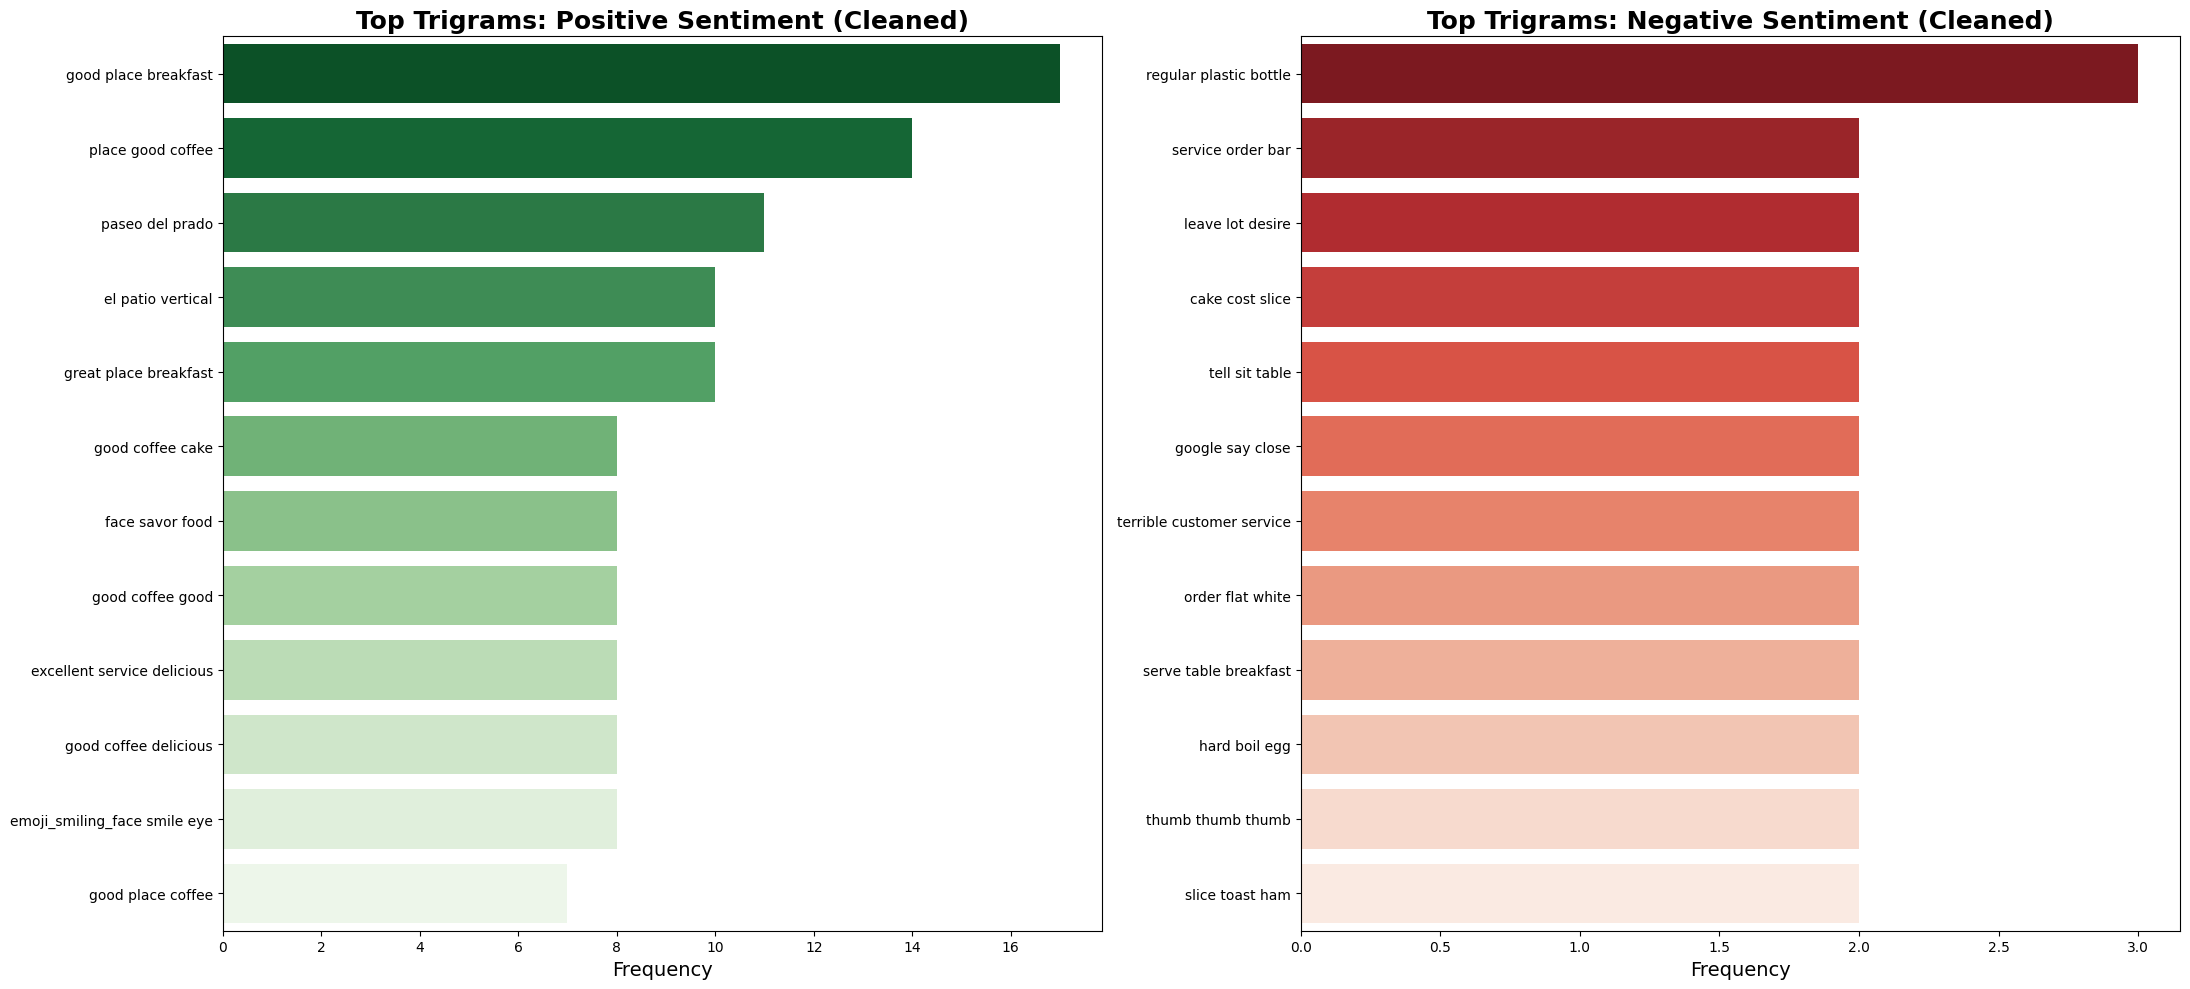

In [13]:
# Redefine the plotting function to accept a column name
def plot_sentiment_ngrams_v2(df, col_name, n=3, top_k=15):
    # Prepare Data by Sentiment
    pos_reviews = df[df['sentiment_3way'] == 'pos'][col_name].fillna('')
    neg_reviews = df[df['sentiment_3way'] == 'neg'][col_name].fillna('')

    def get_top_ngrams(corpus, n_val, k):
        # We handle empty corpuses to avoid errors
        if corpus.empty or (corpus == "").all():
            return [("no_data", 0)]

        vec = CountVectorizer(ngram_range=(n_val, n_val), stop_words='english').fit(corpus)
        bag_of_words = vec.transform(corpus)
        sum_words = bag_of_words.sum(axis=0)
        words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
        words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
        return words_freq[:k]

    # Get data for plots
    df_pos = pd.DataFrame(get_top_ngrams(pos_reviews, n, top_k), columns=['Ngram', 'Count'])
    df_neg = pd.DataFrame(get_top_ngrams(neg_reviews, n, top_k), columns=['Ngram', 'Count'])

    # Create Side-by-Side Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))

    label = "Bigrams" if n == 2 else "Trigrams"

    # Positive Plot (Green)
    sns.barplot(x='Count', y='Ngram', data=df_pos, ax=ax1, palette='Greens_r')
    ax1.set_title(f'Top {label}: Positive Sentiment (Cleaned)', fontsize=18, fontweight='bold')
    ax1.set_xlabel('Frequency', fontsize=14)
    ax1.set_ylabel('')

    # Negative Plot (Red)
    sns.barplot(x='Count', y='Ngram', data=df_neg, ax=ax2, palette='Reds_r')
    ax2.set_title(f'Top {label}: Negative Sentiment (Cleaned)', fontsize=18, fontweight='bold')
    ax2.set_xlabel('Frequency', fontsize=14)
    ax2.set_ylabel('')

    plt.tight_layout()
    plt.show()

# Re-apply the Metadata Cleaner to ensure it reaches inside the 'emoji_' tokens
METADATA_PATTERN = r'(_medium|_skin|_tone|_light|_dark|_fitzpatrick|_type|_modifier)'
EMOJI_METADATA_LIST = ['medium', 'skin', 'tone', 'light', 'dark', 'fitzpatrick', 'type']

def final_clean_for_tfm_viz(text):
    if not isinstance(text, str): return ""
    # Remove internal metadata (e.g., _medium_skin_tone)
    text = re.sub(METADATA_PATTERN, '', text)
    # Remove standalone metadata words
    words = text.split()
    cleaned = [w for w in words if w not in EMOJI_METADATA_LIST]
    return " ".join(cleaned)

# Apply and Plot
df['text_viz_final_v3'] = df['text_final_v2'].apply(final_clean_for_tfm_viz)

plot_sentiment_ngrams_v2(df, 'text_viz_final_v3', n=3, top_k=12)

## CLUSTERING (CODIGO DE 13-01-2026)

In [16]:
# 1. Vectorize the Text (TF-IDF) - max_features=500 keeps it efficient
tfidf = TfidfVectorizer(max_features=500, stop_words='english')
text_vectors = tfidf.fit_transform(df['text_en_with_emoji'])

# 2. Encode Sentiment (One-Hot Encoding) - turns 'pos' into [1, 0, 0], 'neu' into [0, 1, 0], etc.
encoder = OneHotEncoder()
sentiment_vectors = encoder.fit_transform(df[['sentiment_3way']])

# 3. Combine Text and Sentiment features
combined_features = sp.hstack((text_vectors, sentiment_vectors))

# 4. Run K-Means Clustering
num_clusters = 4
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(combined_features)

print(f"Clustering complete! {num_clusters} groups identified.")

Clustering complete! 4 groups identified.


In [17]:
# Function to show top words per cluster
def get_top_keywords(n_terms):
    df_clusters = pd.DataFrame(combined_features.todense()).groupby(df['cluster'].values).mean()
    terms = tfidf.get_feature_names_out()

    # Add sentiment names to terms list to correctly map all combined features
    terms = list(terms) + list(encoder.get_feature_names_out())

    for i, r in df_clusters.iterrows():
        print(f"\nCluster {i}:")
        print(", ".join([terms[t] for t in np.argsort(r)[:-(n_terms+1):-1]]))


get_top_keywords(10)


Cluster 0:
sentiment_3way_pos, place, delicious, coffee, excellent, great, service, friendly, nice, staff

Cluster 1:
sentiment_3way_neu, good, coffee, expensive, place, nice, bit, small, service, breakfast

Cluster 2:
sentiment_3way_pos, good, service, coffee, place, breakfast, excellent, food, nice, friendly

Cluster 3:
sentiment_3way_neg, expensive, coffee, bad, euros, like, didn, terrible, don, service


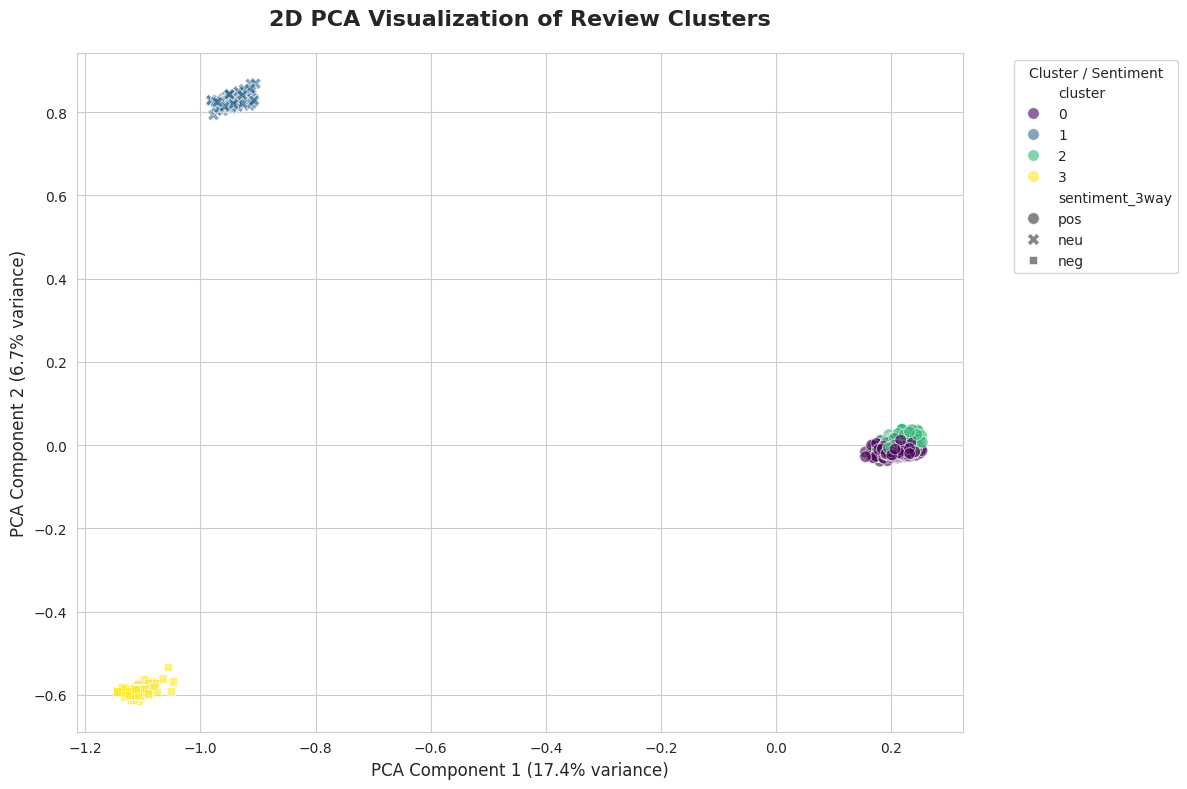

In [18]:
# Visualizing

# 1. Initialize PCA to reduce data to 2 dimensions
pca = PCA(n_components=2, random_state=42)

# 2. Transform the combined features (TF-IDF + Sentiment) - .toarray() because PCA needs a dense matrix
pca_data = pca.fit_transform(combined_features.toarray())

# 3. Add the PCA coordinates to the DataFrame
df['pca_x'] = pca_data[:, 0]
df['pca_y'] = pca_data[:, 1]

# 4. Create the Plot
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# 'hue' for the clusters and 'style' for the sentiment, to see if clusters are topic-based or sentiment-based
scatter = sns.scatterplot(
    data=df,
    x='pca_x',
    y='pca_y',
    hue='cluster',
    style='sentiment_3way',
    palette='viridis',
    s=70,
    alpha=0.6,
    edgecolor='w'
)

# 5. Add Titles and Labels
plt.title("2D PCA Visualization of Review Clusters", fontsize=16, fontweight='bold', pad=20)
plt.xlabel(f"PCA Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)", fontsize=12)
plt.ylabel(f"PCA Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)", fontsize=12)

# Move legend outside to keep the plot clean
plt.legend(title="Cluster / Sentiment", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

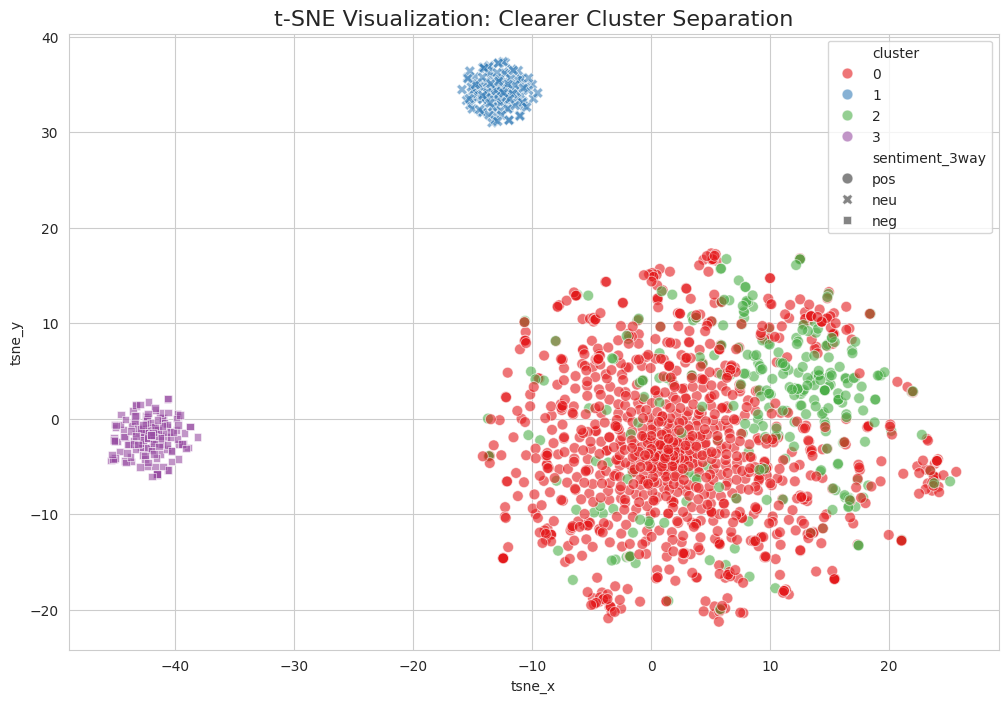


Cluster 0:
sentiment_3way_pos, place, delicious, coffee, excellent, great, service, friendly, nice, staff, breakfast, food

Cluster 1:
sentiment_3way_neu, good, coffee, expensive, place, nice, bit, small, service, breakfast, location, toast

Cluster 2:
sentiment_3way_pos, good, service, coffee, place, breakfast, excellent, food, nice, friendly, cakes, prices

Cluster 3:
sentiment_3way_neg, expensive, coffee, bad, euros, like, didn, terrible, don, service, rude, good


In [19]:
# Use t-SNE (the "gold standard" for text clusters) as a second view on the same combined_features
# Note: this can take a minute if you have >5000 rows
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
tsne_data = tsne.fit_transform(combined_features.toarray())

df['tsne_x'] = tsne_data[:, 0]
df['tsne_y'] = tsne_data[:, 1]

# Plot t-SNE
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df,
    x='tsne_x', y='tsne_y',
    hue='cluster',
    style='sentiment_3way',
    palette='Set1',  # High contrast colors
    s=60,
    alpha=0.6
)
plt.title("t-SNE Visualization: Clearer Cluster Separation", fontsize=16)
plt.show()

get_top_keywords(12)

# PREDICTION MODEL FOR SENTIMENT ANALYSIS FROM WRITTEN TEXT

## Model 1: Logistics Regression

--- Classification Report ---
              precision    recall  f1-score   support

         neg       0.58      0.73      0.65        30
         neu       0.37      0.46      0.41        24
         pos       0.94      0.89      0.92       273

    accuracy                           0.85       327
   macro avg       0.63      0.70      0.66       327
weighted avg       0.87      0.85      0.86       327



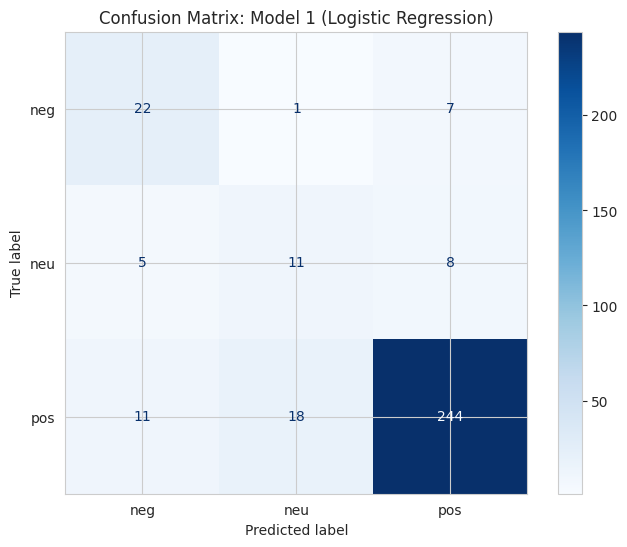

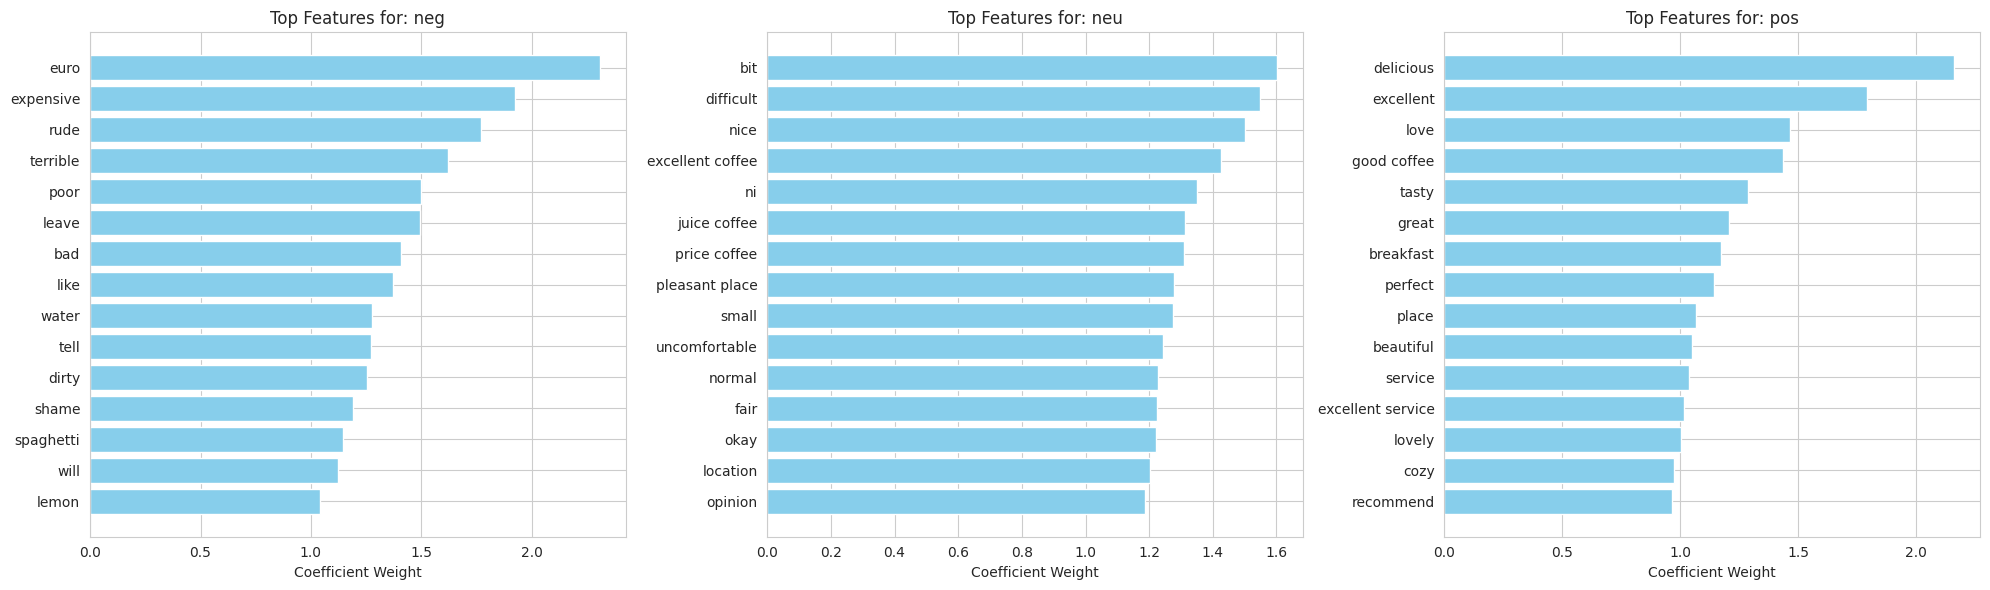

In [21]:
# --- Preprocessing Setup (spaCy-based, same as the emoji preprocessing step above) ---
def get_dynamic_emoji_phrases(df, top_n=20):
    all_text = " ".join(df['text_en_with_emoji'].fillna('').astype(str))
    words = all_text.split()
    bigrams = zip(words, words[1:])
    counts = Counter(bigrams)
    emoji_keywords = {'heart', 'face', 'star', 'hands', 'smiling', 'eyes', 'thumb', 'skull', 'rolling', 'angry', 'sad', 'cry', 'pouting', 'weary', 'broken', 'expressionless', 'thinking', 'middle'}
    detected = [f"{w1} {w2}" for (w1, w2), count in counts.most_common(100) if w1 in emoji_keywords or w2 in emoji_keywords]
    return list(set(detected + ["red heart", "smiling face", "heart eyes"]))

df = pd.read_csv('cleaned_reviews_df_v20260114_2016PM.tsv', sep='\t')
EMOJI_PHRASES = get_dynamic_emoji_phrases(df)

def join_emoji_phrases_v3(text):
    if not isinstance(text, str): return ""
    sorted_phrases = sorted(EMOJI_PHRASES, key=len, reverse=True)
    for phrase in sorted_phrases:
        pattern = r'\b' + re.escape(phrase) + r'\b'
        text = re.sub(pattern, "emoji_" + phrase.replace(" ", "_"), text)
    return text.replace("emoji_emoji_", "emoji_")

@Language.component("emoji_preserver")
def emoji_preserver(doc):
    for token in doc:
        if "emoji_" in token.text:
            token.lemma_ = token.text
            token.vocab[token.text].is_stop = False
    return doc

if "emoji_preserver" not in nlp.pipe_names:
    nlp.add_pipe("emoji_preserver", before="lemmatizer")

def preprocess_v2(text):
    text = join_emoji_phrases_v3(text)
    doc = nlp(text)
    clean_tokens = []
    for token in doc:
        if "emoji_" in token.text:
            clean_tokens.append(token.text)
        elif not token.is_stop and not token.is_punct and token.is_alpha:
            lemma = token.lemma_.lower()
            if len(lemma) > 1:
                clean_tokens.append(lemma)
    return " ".join(clean_tokens)

# Apply Preprocessing
df['text_final_v2'] = df['text_en_with_emoji'].apply(preprocess_v2)

# --- Vectorization & Training ---
X = df['text_final_v2']
y = df['sentiment_3way']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

tfidf = TfidfVectorizer(max_features=1500, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Model
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)

# Predictions
y_pred = model.predict(X_test_tfidf)

# --- Evaluation ---
report = classification_report(y_test, y_pred, output_dict=True)
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(model, X_test_tfidf, y_test, cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Model 1 (Logistic Regression)')
plt.savefig('confusion_matrix_model1.png')

# --- Feature Importance ---
def plot_feature_importance(model, vectorizer, class_labels):
    feature_names = vectorizer.get_feature_names_out()
    fig, axes = plt.subplots(1, len(class_labels), figsize=(20, 6))

    for i, class_label in enumerate(model.classes_):
        coefs = model.coef_[i]
        top_indices = np.argsort(coefs)[-15:]
        top_features = [feature_names[j] for j in top_indices]
        top_coefs = [coefs[j] for j in top_indices]

        axes[i].barh(top_features, top_coefs, color='skyblue')
        axes[i].set_title(f"Top Features for: {class_label}")
        axes[i].set_xlabel("Coefficient Weight")

    plt.tight_layout()
    plt.savefig('feature_importance_model1.png')

plot_feature_importance(model, tfidf, model.classes_)

## Model 2: Random Forest

Model 2 (Random Forest) Accuracy: 0.85

Classification Report:
              precision    recall  f1-score     support
neg            0.888889  0.266667  0.410256   30.000000
neu            0.000000  0.000000  0.000000   24.000000
pos            0.862179  0.985348  0.919658  273.000000
accuracy       0.847095  0.847095  0.847095    0.847095
macro avg      0.583689  0.417338  0.443305  327.000000
weighted avg   0.801351  0.847095  0.805426  327.000000

Top 10 Features (Gini Importance):
good                      | 0.0166
expensive                 | 0.0161
and                       | 0.0154
delicious                 | 0.0150
very                      | 0.0147
place                     | 0.0137
the                       | 0.0122
but                       | 0.0119
not                       | 0.0115
they                      | 0.0102


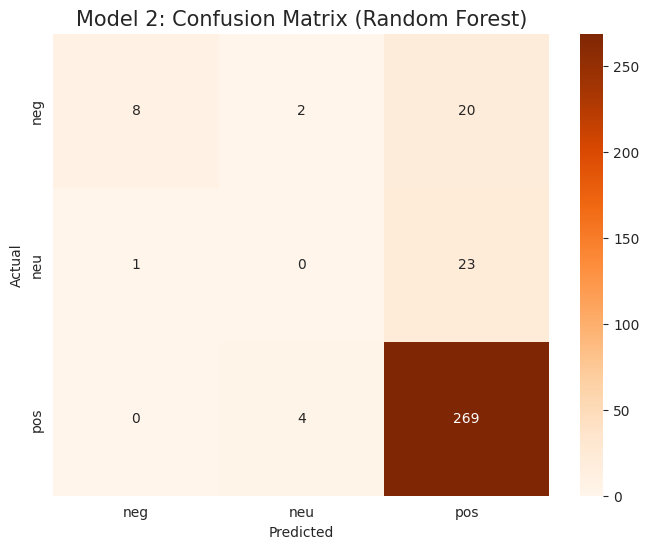

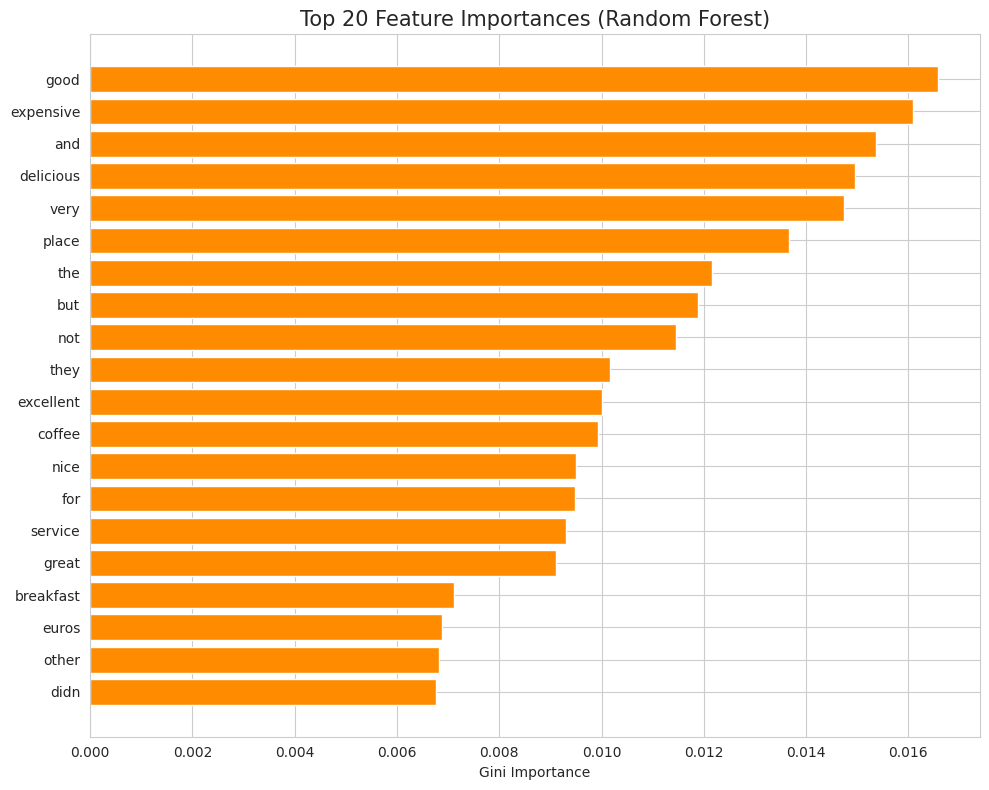

In [24]:
# 1. Load data
file_name = 'cleaned_reviews_df_v20260114_2016PM.tsv'
df = pd.read_csv(file_name, sep='\t')

# 2. Re-apply Preprocessing Logic (regex-based, consistency with Models 3 & 4)
def shield_emojis(text):
    if not isinstance(text, str): return ""
    replacements = {
        r'smiling face with hearts': 'emoji_smiling_face_with_hearts',
        r'smiling face with heart eyes': 'emoji_smiling_face_with_heart_eyes',
        r'face exhaling': 'emoji_face_exhaling',
        r'thumbs up': 'emoji_thumbs_up',
        r'thumbs down': 'emoji_thumbs_down',
        r'red heart': 'emoji_red_heart',
        r'sparkles': 'emoji_sparkles',
        r'clapping hands': 'emoji_clapping_hands',
        r'pensive face': 'emoji_pensive_face',
        r'disappointed face': 'emoji_disappointed_face'
    }
    for pattern, replacement in replacements.items():
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    text = re.sub(r'(_medium|_skin|_tone|_light|_dark|_fitzpatrick|_type|_modifier)', '', text)
    return text

def final_preprocess(text):
    text = shield_emojis(text)
    tokens = text.lower().split()
    noise = ['medium', 'skin', 'tone', 'light', 'dark', 'fitzpatrick', 'type']
    tokens = [t for t in tokens if t not in noise and len(t) > 2]
    return " ".join(tokens)

df['text_final_v2'] = df['text_en_with_emoji'].apply(final_preprocess)

# 3. Train-Test Split
X = df['text_final_v2']
y = df['sentiment_3way']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Vectorization
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 5. Training Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)

# 6. Evaluation
y_pred = rf_model.predict(X_test_tfidf)
acc = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)
cm = confusion_matrix(y_test, y_pred)

print(f"Model 2 (Random Forest) Accuracy: {acc:.2f}")
print("\nClassification Report:")
print(pd.DataFrame(report).transpose())

# 7. Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title('Model 2: Confusion Matrix (Random Forest)', fontsize=15)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix_model2_rf.png')

# 8. Feature Importance (MDI)
importances = rf_model.feature_importances_
feature_names = tfidf.get_feature_names_out()
indices = np.argsort(importances)[-20:][::-1]

plt.figure(figsize=(10, 8))
plt.title('Top 20 Feature Importances (Random Forest)', fontsize=15)
plt.barh(range(20), importances[indices], align='center', color='darkorange')
plt.yticks(range(20), [feature_names[i] for i in indices])
plt.xlabel('Gini Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance_rf.png')

print("\nTop 10 Features (Gini Importance):")
for i in range(10):
    print(f"{feature_names[indices[i]]:25} | {importances[indices[i]]:.4f}")

## Model 3: XGBoost

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [21:24:54] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model 3 Accuracy (XGBoost): 0.87

Classification Report:
              precision    recall  f1-score     support
neg            0.722222  0.433333  0.541667   30.000000
neu            0.250000  0.041667  0.071429   24.000000
pos            0.885246  0.989011  0.934256  273.000000
accuracy       0.868502  0.868502  0.868502    0.868502
macro avg      0.619156  0.488004  0.515784  327.000000
weighted avg   0.823666  0.868502  0.834912  327.000000

--- Top 20 Feature Importances (XGBoost Gain) ---
expensive                 | Importance: 0.0227
won                       | Importance: 0.0194
charge                    | Importance: 0.0190
was bit                   | Importance: 0.0163
waitress                  | Importance: 0.0152
rude                      | Importance: 0.0149
not                       | Importance: 0.0147
the price                 | Importance: 0.0144
euros                     | Importance: 0.0131
think                     | Importance: 0.0128
don                       | Im

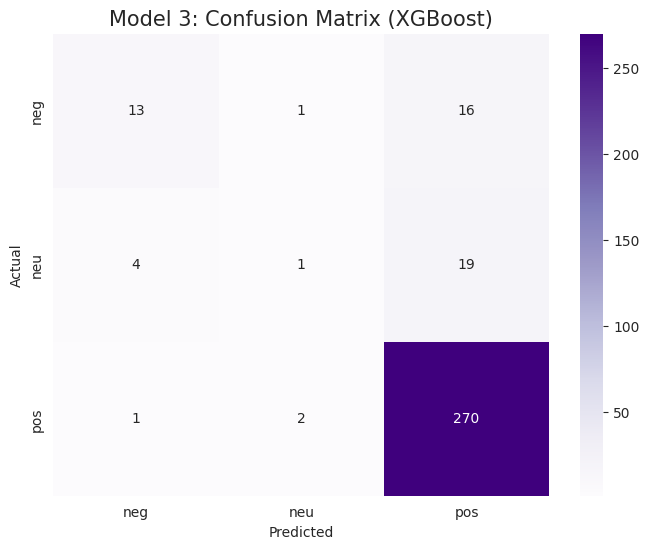

In [26]:
# Load data
file_name = 'cleaned_reviews_df_v20260114_2016PM.tsv'
df = pd.read_csv(file_name, sep='\t')

# --- PREPROCESSING (same regex-based preprocessing as Model 2 / Random Forest) ---
def shield_emojis(text):
    if not isinstance(text, str): return ""
    replacements = {
        r'smiling face with hearts': 'emoji_smiling_face_with_hearts',
        r'smiling face with heart eyes': 'emoji_smiling_face_with_heart_eyes',
        r'face exhaling': 'emoji_face_exhaling',
        r'thumbs up': 'emoji_thumbs_up',
        r'thumbs down': 'emoji_thumbs_down',
        r'red heart': 'emoji_red_heart',
        r'sparkles': 'emoji_sparkles',
        r'clapping hands': 'emoji_clapping_hands',
        r'pensive face': 'emoji_pensive_face',
        r'disappointed face': 'emoji_disappointed_face'
    }
    for pattern, replacement in replacements.items():
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    text = re.sub(r'(_medium|_skin|_tone|_light|_dark|_fitzpatrick|_type|_modifier)', '', text)
    return text

def final_preprocess(text):
    text = shield_emojis(text)
    tokens = text.lower().split()
    noise = ['medium', 'skin', 'tone', 'light', 'dark', 'fitzpatrick', 'type']
    tokens = [t for t in tokens if t not in noise and len(t) > 2]
    return " ".join(tokens)

df['text_final_v2'] = df['text_en_with_emoji'].apply(final_preprocess)

# --- MODEL 3: XGBOOST ---

X = df['text_final_v2']
y = df['sentiment_3way']

# XGBoost requires numeric labels [0, 1, 2]
le = LabelEncoder()
y_encoded = le.fit_transform(y)
# le.classes_ will be ['neg', 'neu', 'pos'] -> 0, 1, 2

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Vectorization
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    objective='multi:softprob',
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train_tfidf, y_train)

# Evaluation
y_pred = xgb_model.predict(X_test_tfidf)
acc = accuracy_score(y_test, y_pred)
# Convert numeric predictions back to labels for report
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred)

report = classification_report(y_test_labels, y_pred_labels, output_dict=True)
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=le.classes_)

print(f"Model 3 Accuracy (XGBoost): {acc:.2f}")
print("\nClassification Report:")
print(pd.DataFrame(report).transpose())

# Visualization of Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Model 3: Confusion Matrix (XGBoost)', fontsize=15)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix_xgb_model.png')

# Feature Importance (Weight-based)
importances = xgb_model.feature_importances_
feature_names = tfidf.get_feature_names_out()
indices = np.argsort(importances)[-20:][::-1]

print("\n--- Top 20 Feature Importances (XGBoost Gain) ---")
for i in indices:
    print(f"{feature_names[i]:25} | Importance: {importances[i]:.4f}")

## Model 4: Support Vector Machine (SVM)

Accuracy: 0.8899

Classification Report:
              precision    recall  f1-score   support

         neg       0.68      0.63      0.66        30
         neu       0.46      0.25      0.32        24
         pos       0.93      0.97      0.95       273

    accuracy                           0.89       327
   macro avg       0.69      0.62      0.64       327
weighted avg       0.87      0.89      0.88       327


--- Top 15 Predictors for NEGATIVE Sentiment ---
euros                     | Weight: 1.907
terrible                  | Weight: 1.571
don                       | Weight: 1.491
poor                      | Weight: 1.419
expensive                 | Weight: 1.402
rude                      | Weight: 1.344
acceptable                | Weight: 1.309
they                      | Weight: 1.251
other                     | Weight: 1.243
not very                  | Weight: 1.158
dirty                     | Weight: 1.095
didn                      | Weight: 1.069
down                    

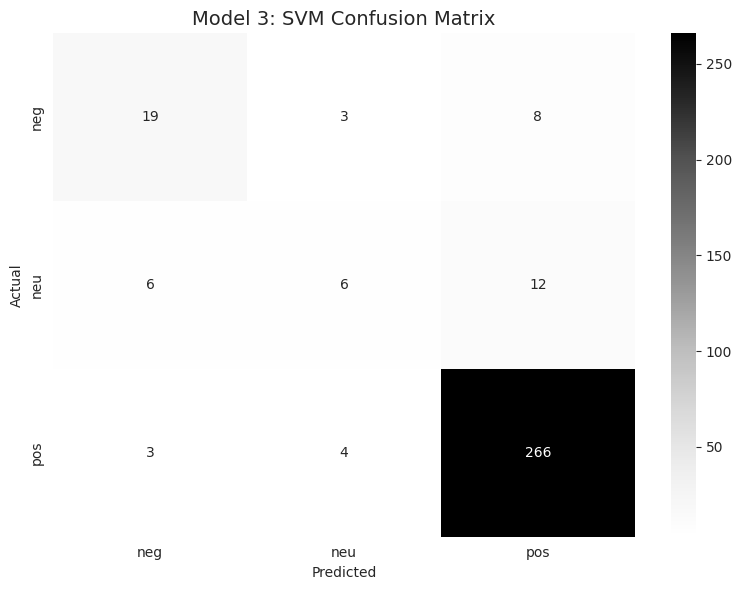

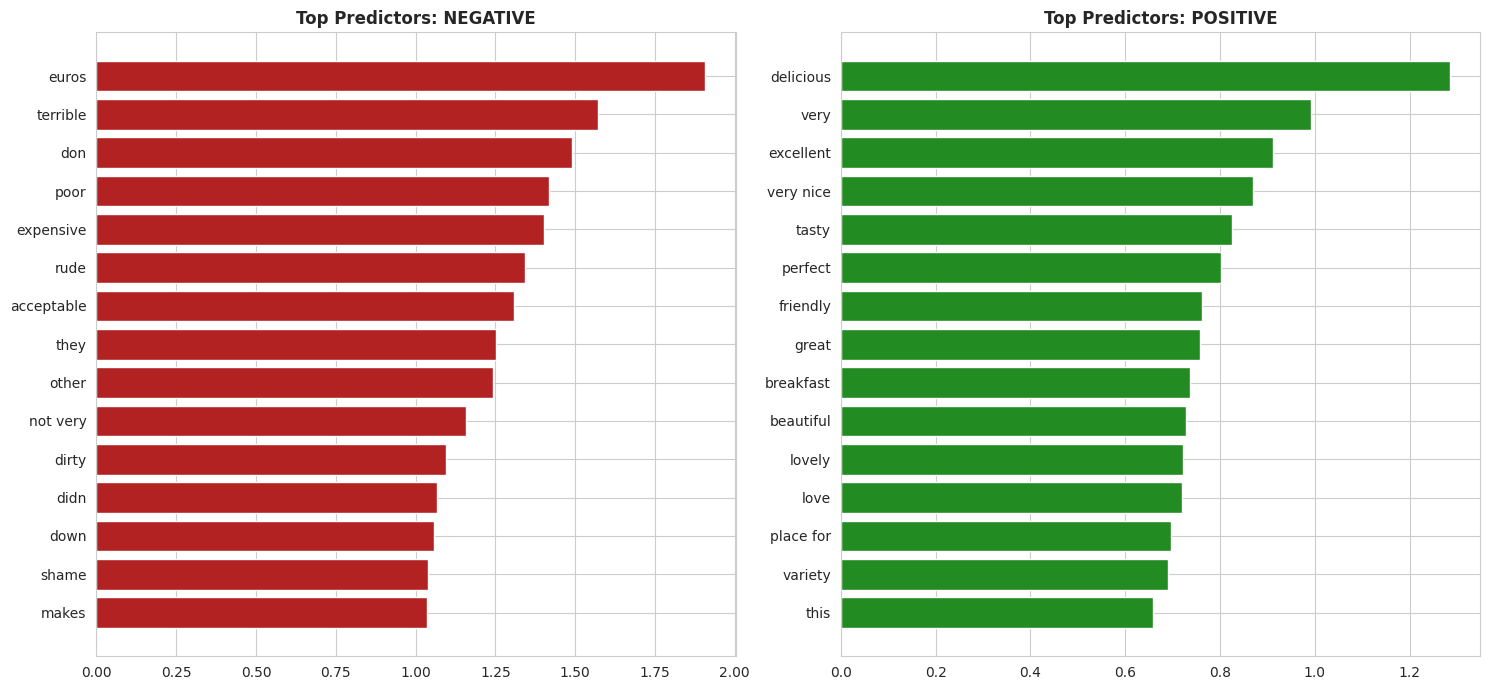

In [32]:
# Load data
file_name = 'cleaned_reviews_df_v20260114_2016PM.tsv'
df = pd.read_csv(file_name, sep='\t')

# Preprocessing
def shield_emojis(text):
    if not isinstance(text, str): return ""
    replacements = {
        r'smiling face with hearts': 'emoji_hearts',
        r'smiling face with heart eyes': 'emoji_heart_eyes',
        r'face exhaling': 'emoji_exhaling',
        r'thumbs up': 'emoji_thumbs_up',
        r'thumbs down': 'emoji_thumbs_down',
        r'red heart': 'emoji_red_heart',
        r'sparkles': 'emoji_sparkles',
        r'clapping hands': 'emoji_clapping',
        r'pensive face': 'emoji_pensive',
        r'disappointed face': 'emoji_disappointed'
    }
    for pattern, replacement in replacements.items():
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    text = re.sub(r'(_medium|_skin|_tone|_light|_dark|_fitzpatrick|_type|_modifier)', '', text)
    return text

def final_preprocess(text):
    text = shield_emojis(text)
    tokens = text.lower().split()
    noise = ['medium', 'skin', 'tone', 'light', 'dark', 'fitzpatrick', 'type']
    tokens = [t for t in tokens if t not in noise and len(t) > 2]
    return " ".join(tokens)

df['text_final'] = df['text_en_with_emoji'].apply(final_preprocess)

# Split & Vectorize
X = df['text_final']
y = df['sentiment_3way']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Model 3: SVM
svm_model = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
svm_model.fit(X_train_tfidf, y_train)

# Results
y_pred = svm_model.predict(X_test_tfidf)
acc = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(report)

# Confusion Matrix Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greys',
            xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
plt.title('Model 3: SVM Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('svm_confusion_matrix_report.png')

# Feature Importance
feature_names = tfidf.get_feature_names_out()

def get_top_features(cls_label):
    cls_idx = list(svm_model.classes_).index(cls_label)
    coefs = svm_model.coef_[cls_idx]
    top_indices = np.argsort(coefs)[-15:][::-1]
    return [(feature_names[i], coefs[i]) for i in top_indices]

neg_features = get_top_features('neg')
pos_features = get_top_features('pos')

print("\n--- Top 15 Predictors for NEGATIVE Sentiment ---")
for word, score in neg_features:
    print(f"{word:25} | Weight: {score:.3f}")

print("\n--- Top 15 Predictors for POSITIVE Sentiment ---")
for word, score in pos_features:
    print(f"{word:25} | Weight: {score:.3f}")

# Feature Importance Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
words_n, scores_n = zip(*neg_features[::-1])
ax1.barh(words_n, scores_n, color='firebrick')
ax1.set_title('Top Predictors: NEGATIVE', fontweight='bold')

words_p, scores_p = zip(*pos_features[::-1])
ax2.barh(words_p, scores_p, color='forestgreen')
ax2.set_title('Top Predictors: POSITIVE', fontweight='bold')
plt.tight_layout()
plt.savefig('svm_feature_importance_report.png')

## Model Comparison

In [34]:
# Data manually collected from each model's classification report above

# Model 1: Logistic Regression
log_reg_metrics = {
    'Accuracy': 0.85,
    'Precision (weighted avg)': 0.87,
    'Recall (weighted avg)': 0.85,
    'F1-Score (weighted avg)': 0.86,
    'Precision (neg)': 0.58,
    'Recall (neg)': 0.73,
    'F1-Score (neg)': 0.65,
    'Precision (neu)': 0.37,
    'Recall (neu)': 0.46,
    'F1-Score (neu)': 0.41,
    'Precision (pos)': 0.94,
    'Recall (pos)': 0.89,
    'F1-Score (pos)': 0.92
}

# Model 2: Random Forest
rf_metrics = {
    'Accuracy': 0.85,  # Rounded from 0.847095
    'Precision (weighted avg)': 0.80,  # Rounded from 0.801351
    'Recall (weighted avg)': 0.85,  # Rounded from 0.847095
    'F1-Score (weighted avg)': 0.81,  # Rounded from 0.805426
    'Precision (neg)': 0.89,
    'Recall (neg)': 0.27,
    'F1-Score (neg)': 0.41,
    'Precision (neu)': 0.00,
    'Recall (neu)': 0.00,
    'F1-Score (neu)': 0.00,
    'Precision (pos)': 0.86,
    'Recall (pos)': 0.99,
    'F1-Score (pos)': 0.92
}

# Model 3: XGBoost
xgb_metrics = {
    'Accuracy': 0.87,  # Rounded from 0.868502
    'Precision (weighted avg)': 0.82,  # Rounded from 0.823666
    'Recall (weighted avg)': 0.87,  # Rounded from 0.868502
    'F1-Score (weighted avg)': 0.83,  # Rounded from 0.834912
    'Precision (neg)': 0.72,
    'Recall (neg)': 0.43,
    'F1-Score (neg)': 0.54,
    'Precision (neu)': 0.25,
    'Recall (neu)': 0.04,
    'F1-Score (neu)': 0.07,
    'Precision (pos)': 0.89,
    'Recall (pos)': 0.99,
    'F1-Score (pos)': 0.93
}

# Model 4: Support Vector Machine (SVM)
svm_metrics = {
    'Accuracy': 0.89,  # Rounded from 0.8899
    'Precision (weighted avg)': 0.87,
    'Recall (weighted avg)': 0.89,
    'F1-Score (weighted avg)': 0.88,
    'Precision (neg)': 0.68,
    'Recall (neg)': 0.63,
    'F1-Score (neg)': 0.66,
    'Precision (neu)': 0.46,
    'Recall (neu)': 0.25,
    'F1-Score (neu)': 0.32,
    'Precision (pos)': 0.93,
    'Recall (pos)': 0.97,
    'F1-Score (pos)': 0.95
}

# Create a dictionary of all metrics
all_metrics = {
    'Logistic Regression': log_reg_metrics,
    'Random Forest': rf_metrics,
    'XGBoost': xgb_metrics,
    'SVM': svm_metrics
}

# Convert to DataFrame for a clean comparison table
comparison_df = pd.DataFrame(all_metrics).T  # .T for transpose to have models as index

print("--- Model Comparison Report ---")
display(comparison_df.round(2))

--- Model Comparison Report ---


,Accuracy,Precision (weighted avg),Recall (weighted avg),F1-Score (weighted avg),Precision (neg),Recall (neg),F1-Score (neg),Precision (neu),Recall (neu),F1-Score (neu),Precision (pos),Recall (pos),F1-Score (pos)
Logistic Regression,0.85,0.87,0.85,0.86,0.58,0.73,0.65,0.37,0.46,0.41,0.94,0.89,0.92
Random Forest,0.85,0.80,0.85,0.81,0.89,0.27,0.41,0.00,0.00,0.00,0.86,0.99,0.92
XGBoost,0.87,0.82,0.87,0.83,0.72,0.43,0.54,0.25,0.04,0.07,0.89,0.99,0.93
SVM,0.89,0.87,0.89,0.88,0.68,0.63,0.66,0.46,0.25,0.32,0.93,0.97,0.95


## Sentiment Word CLoud

Saved wordcloud_positive.png
Saved wordcloud_neutral.png
Saved wordcloud_negative.png


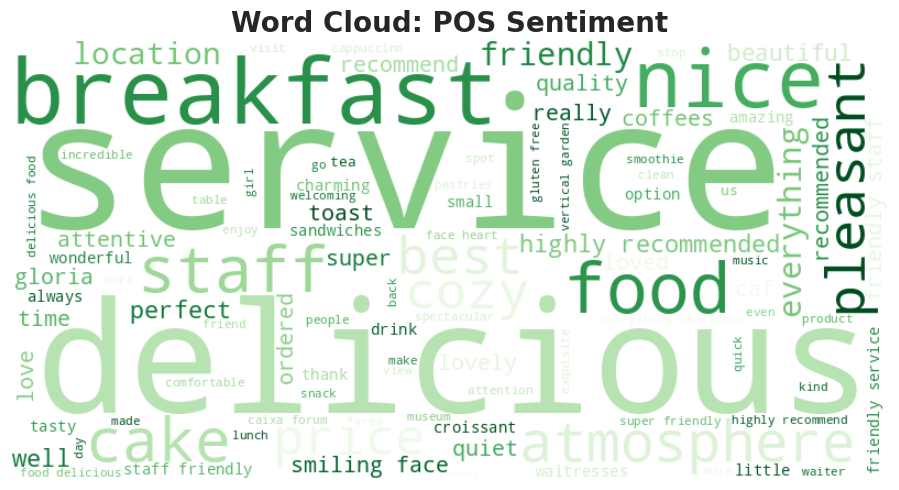

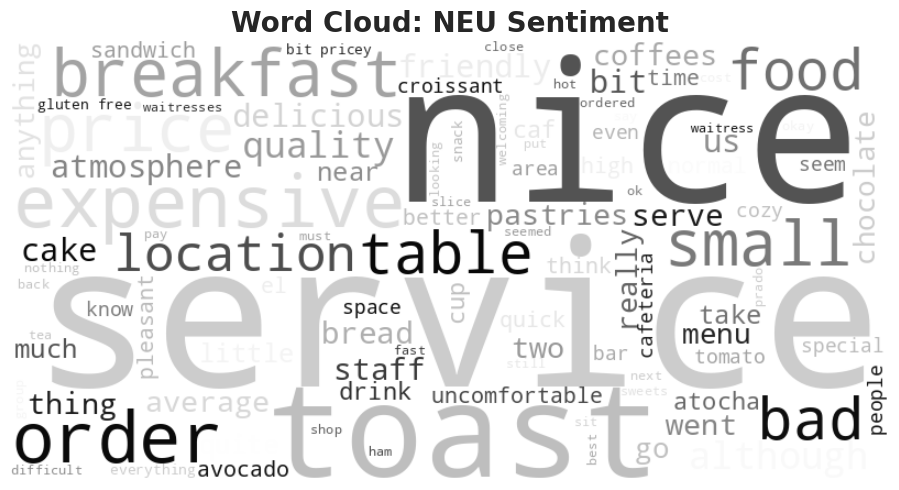

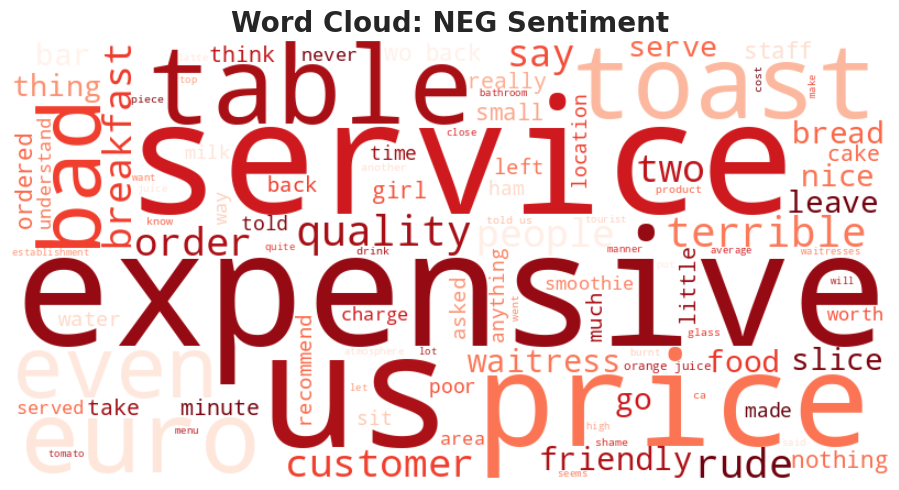

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import spacy

# Load data
file_name = 'cleaned_reviews_df_v20260114_2016PM.tsv'
df = pd.read_csv(file_name, sep='\t')

# Load spacy for stopword removal and basic cleaning
nlp = spacy.load("en_core_web_sm")
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(["place", "coffee", "madrid", "cafe", "good", "great", "excellent", "very", "one", "brunch"])

def get_sentiment_text(sentiment):
    text = " ".join(df[df['sentiment_3way'] == sentiment]['text_en_with_emoji'].astype(str))
    # Basic tokenization and stopword removal
    doc = nlp(text.lower())
    cleaned_text = " ".join([token.text for token in doc if token.is_alpha and token.text not in custom_stopwords])
    return cleaned_text

# Generate Word Clouds
sentiments = [('pos', 'Greens', 'wordcloud_positive.png'),
              ('neu', 'Greys', 'wordcloud_neutral.png'),
              ('neg', 'Reds', 'wordcloud_negative.png')]

for sent, cmap, filename in sentiments:
    text = get_sentiment_text(sent)
    if text:
        wc = WordCloud(width=800, height=400, background_color='white',
                       colormap=cmap, stopwords=custom_stopwords,
                       max_words=100, contour_width=3, contour_color='steelblue').generate(text)
        plt.figure(figsize=(10, 5))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Word Cloud: {sent.upper()} Sentiment', fontsize=20, fontweight='bold')
        plt.tight_layout()
        plt.savefig(filename)
        print(f"Saved {filename}")
    else:
        print(f"No text found for sentiment {sent}")